# K-shot curves of one experiment on one chip set

Reads `results/<EXPERIMENT>/<CHIPS>/`, as written by `scripts/run_kshot.py` on the JupyterHub or pulled back from the
cluster with `scripts/cluster/pull_results.sh`, refreshes its `summary.csv`, and plots test Macro-F1 and mIoU
against the label budget K for every arm. Change the two parameters below to read another run, for example
`CHIPS = "EE_2021"` once the full-Estonia experiment has run. Where a cell has several draws or seeds the curve is
their mean and the band their range.

Line style follows the resolution group of the decoder input: solid for the 160 m token grid (TerraMind, Prithvi,
THOR), dash-dot for THOR on 80 m tokens, dashed for the 10 m pixel rasters (TESSERA, AlphaEarth). A gap between
groups is not attributable to the encoder alone.

In [1]:
EXPERIMENT = "kshot"
CHIPS = "EE_2021_mini"

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
sys.path.insert(0, str(REPO / "src"))
from gfm4agri.benchmark.backbones import get_backbone
from gfm4agri.pipeline.runner import summarise

OUT = REPO / "results" / EXPERIMENT / CHIPS
df = summarise(OUT)                      # one row per finished cell; also rewrites summary.csv
first = json.loads(next(OUT.glob("*/P*/results.json")).read_text())
chips = first["split_protocol"]["chips"]
print(f"{len(df)} cells in {OUT.relative_to(REPO)}; split {first['split_protocol']['split']}: "
      f"{chips['training']} training, {chips['validation']} validation, {chips['test']} test chips")
print("machines:", ", ".join(sorted(df["machine"].dropna().unique())),
      "| commits:", ", ".join(sorted(c[:8] for c in df["git_commit"].dropna().unique())))

18 cells in results/kshot/EE_2021_mini; split blocks4_buf1600_seed0__6b0eb4cb: 32 training, 16 validation, 9 test chips
machines: hub | commits: 0250e4c6, 3a367ff2


In [3]:
# Each arm keeps its colour in every run (categorical slots 1 to 6, validated for adjacent lines).
ARMS = {
    "terramind_v1_large":   ("TerraMind v1 large",      "#2a78d6", "o"),
    "prithvi_eo_v2_600_tl": ("Prithvi-EO-2.0 600M TL",  "#eb6834", "s"),
    "thor_v1_large":        ("THOR v1 large, 160 m",    "#1baf7a", "D"),
    "thor_v1_large_80m":    ("THOR v1 large, 80 m",     "#008300", "h"),
    "tessera_v1":           ("TESSERA v1 + MLP",        "#eda100", "^"),
    "alphaearth_v1":        ("AlphaEarth v1 + MLP",     "#e87ba4", "v"),
}
#: Line style by resolution group of the decoder input.
STYLE = {"token_grid": "-", "token_grid_80m": "-.", "pixel_raster": "--"}
INK, INK_2, GRID, SURFACE = "#0b0b0b", "#52514e", "#e4e3df", "#fcfcfb"
LABEL = {a: v[0] for a, v in ARMS.items()}
arms = [a for a in ARMS if a in set(df["arm"])] + sorted(set(df["arm"]) - set(ARMS))

def table(metric):
    t = df.groupby(["arm", "pct"])[metric].mean().unstack("pct")
    t = t.reindex(arms)[sorted(t.columns, reverse=True)]
    t.index = [LABEL.get(a, a) for a in t.index]
    t.columns = [f"K = {c:g} %" for c in t.columns]
    return t.round(3)

print("Test Macro-F1"); display(table("macro_f1"))
print("Test mIoU");     display(table("miou"))
budget = df.groupby("pct")[["train_chips", "parcels"]].first().sort_index(ascending=False)
budget.index = [f"K = {k:g} %" for k in budget.index]
print("Training chips and parcels drawn per budget (draw 0)"); display(budget)

Test Macro-F1


,K = 100 %,K = 20 %,K = 5 %
TerraMind v1 large,0.132,0.150,0.083
Prithvi-EO-2.0 600M TL,0.101,0.077,0.088
"THOR v1 large, 160 m",0.129,0.071,0.096
"THOR v1 large, 80 m",0.146,0.110,0.109
TESSERA v1 + MLP,0.164,0.155,0.147
AlphaEarth v1 + MLP,0.161,0.126,0.132


Test mIoU


,K = 100 %,K = 20 %,K = 5 %
TerraMind v1 large,0.101,0.111,0.056
Prithvi-EO-2.0 600M TL,0.074,0.055,0.062
"THOR v1 large, 160 m",0.107,0.049,0.068
"THOR v1 large, 80 m",0.121,0.079,0.085
TESSERA v1 + MLP,0.132,0.124,0.115
AlphaEarth v1 + MLP,0.135,0.111,0.106


Training chips and parcels drawn per budget (draw 0)


,train_chips,parcels
K = 100 %,32,697
K = 20 %,29,148
K = 5 %,21,44


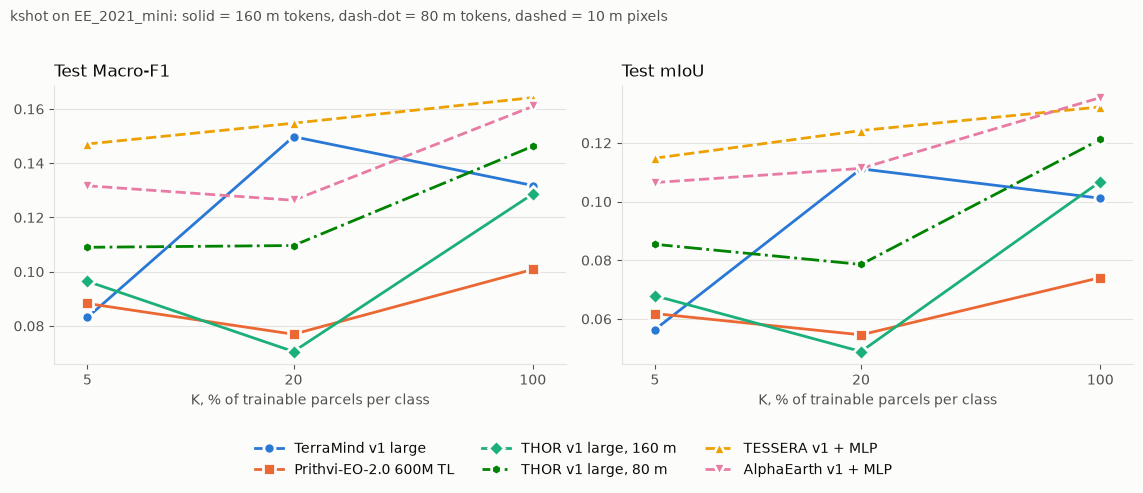

In [4]:
budgets = sorted(df["pct"].unique())
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8), sharex=True, facecolor=SURFACE)
for ax, (metric, title) in zip(axes, [("macro_f1", "Test Macro-F1"), ("miou", "Test mIoU")]):
    ax.set_facecolor(SURFACE)
    for arm in arms:
        label, colour, marker = ARMS.get(arm, (arm, INK_2, "o"))
        g = df[df["arm"] == arm].groupby("pct")[metric]
        mean, lo, hi = g.mean(), g.min(), g.max()
        if (g.count() > 1).any():
            ax.fill_between(mean.index, lo, hi, color=colour, alpha=0.15, lw=0)
        ax.plot(mean.index, mean.values, STYLE[get_backbone(arm).resolution_group], color=colour, lw=2, marker=marker,
                ms=8, mec=SURFACE, mew=2, label=label, zorder=3)
    ax.set_xscale("log")
    ax.set_xticks(budgets, [f"{b:g}" for b in budgets])
    ax.minorticks_off()
    ax.set_xlim(min(budgets) / 1.25, max(budgets) * 1.25)
    ax.set_xlabel("K, % of trainable parcels per class", color=INK_2)
    ax.set_title(title, loc="left", color=INK, fontsize=12)
    ax.grid(axis="y", color=GRID, lw=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=INK_2)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=min(len(labels), 3), frameon=False, labelcolor=INK,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"{EXPERIMENT} on {CHIPS}: solid = 160 m tokens, dash-dot = 80 m tokens, dashed = 10 m pixels", x=0.01, ha="left",
             color=INK_2, fontsize=10)
fig.tight_layout(rect=(0, 0.12, 1, 0.96))
plt.show()

**Checkpoint epochs.** The fit keeps the checkpoint of lowest validation loss (`ckpt_epoch`); the epoch of highest
validation Macro-F1 is listed beside it, since the two disagree on full Estonia (pipeline.md, section 10).

In [5]:
ep = df.pivot_table(index="arm", columns="pct", values=["ckpt_epoch", "best_val_f1_epoch"], aggfunc="first")
ep = ep.reindex(arms)
ep.index = [LABEL.get(a, a) for a in ep.index]
ep.columns = [f"{m}, K = {k:g} %" for m, k in ep.columns]
display(ep)

,"best_val_f1_epoch, K = 5 %","best_val_f1_epoch, K = 20 %","best_val_f1_epoch, K = 100 %","ckpt_epoch, K = 5 %","ckpt_epoch, K = 20 %","ckpt_epoch, K = 100 %"
TerraMind v1 large,9,7,11,14,7,13
Prithvi-EO-2.0 600M TL,12,9,14,12,4,7
"THOR v1 large, 160 m",8,3,14,14,4,5
"THOR v1 large, 80 m",13,13,14,14,7,9
TESSERA v1 + MLP,14,14,12,6,14,12
AlphaEarth v1 + MLP,14,11,13,6,3,2
